In [1]:
from sklearn.ensemble import RandomForestClassifier
import cv2 as cv
import numpy as np
import os
import matplotlib.pyplot as plt
from keras.layers import Input, Dense, Conv2D, MaxPool2D, GlobalAveragePooling2D, Dropout, BatchNormalization
from keras.models import Model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
import seaborn as sns
import random



2026-05-03 08:26:38.462974: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777796798.695062      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777796798.772238      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777796799.337100      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777796799.337137      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777796799.337140      57 computation_placer.cc:177] computation placer alr

In [2]:

# ── Data setup ──
i = 0
train_dr = '/kaggle/input/datasets/t2obd1a1253kmit/clean-augmented-anemia-dataset/New_Augmented_Anemia_Dataset/Conjuctiva/Training'
valid_dr = '/kaggle/input/datasets/t2obd1a1253kmit/clean-augmented-anemia-dataset/New_Augmented_Anemia_Dataset/Conjuctiva/Validation'
anemia_data_dir = train_dr + '/Anemic'
non_anemia_data_dir = train_dr + '/Non-Anemic'

for item in os.listdir(anemia_data_dir): i += 1
print(f"Number of training anemic data: {i}")
i = 0
for item in os.listdir(non_anemia_data_dir): i += 1
print(f"Number of training non-anemic data: {i}")

Number of training anemic data: 4219
Number of training non-anemic data: 4037


In [3]:
# ── Data generators ──
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow_from_directory(
    train_dr,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

valid_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    valid_dr,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

Found 8256 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [4]:
# ── Model architecture ──
inputs = Input(shape=(128, 128, 3))

x1 = Conv2D(32, (3,3), padding="same", activation="relu")(inputs)
x1 = BatchNormalization()(x1)
x2 = MaxPool2D(2,2)(x1)

x3 = Conv2D(64, (3,3), padding="same", activation="relu")(x2)
x3 = BatchNormalization()(x3)
x4 = MaxPool2D(2,2)(x3)

x5 = Conv2D(128, (3,3), padding="same", activation="relu")(x4)
x5 = BatchNormalization()(x5)
x6 = MaxPool2D(2,2)(x5)

x7 = Conv2D(256, (3,3), padding="same", activation="relu")(x6)
x7 = BatchNormalization()(x7)
x8 = MaxPool2D(2,2)(x7)

x9  = GlobalAveragePooling2D()(x8)
x10 = Dropout(0.4)(x9)
x11 = Dense(128, activation="relu")(x10)
x12 = Dropout(0.3)(x11)
x13 = Dense(1, activation="sigmoid")(x12)

model = Model(inputs=inputs, outputs=x13)
model.summary()

I0000 00:00:1777796824.634929      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777796824.640984      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [5]:
# ── Compile ──
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

In [6]:

# ── Callbacks ──
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    'model_anemia.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)



In [7]:
# ── Training ──
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=100,
    callbacks=[checkpoint, early_stop, reduce_lr]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1777796830.437540     141 service.cc:152] XLA service 0x7d087c0576b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777796830.437579     141 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777796830.437584     141 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777796831.191489     141 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/258 ━━━━━━━━━━━━━━━━━━━━ 43:25 10s/step - accuracy: 0.6562 - loss: 0.6219 - precision: 0.8182 - recall: 0.5000

I0000 00:00:1777796836.878347     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.5673 - loss: 0.7271 - precision: 0.5516 - recall: 0.5262
Epoch 1: val_loss improved from inf to 1.35306, saving model to model_anemia.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 77s 260ms/step - accuracy: 0.5674 - loss: 0.7270 - precision: 0.5517 - recall: 0.5264 - val_accuracy: 0.5000 - val_loss: 1.3531 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.5894 - loss: 0.6679 - precision: 0.5781 - recall: 0.5993
Epoch 2: val_loss improved from 1.35306 to 1.08971, saving model to model_anemia.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 48s 184ms/step - accuracy: 0.5894 - loss: 0.6678 - precision: 0.5782 - recall: 0.5994 - val_accuracy: 0.5010 - val_loss: 1.0897 - val_precision: 1.0000 - val_recall: 0.0020 - learning_rate: 1.0000e-04
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.6494 - loss: 0.6208 - precision: 0.6340 - recall: 0.6

In [8]:

# ── Load best model ──
from tensorflow.keras.models import load_model
model = load_model('model_anemia.keras')

# ── Save & download ──
from IPython.display import FileLink, display
import os

print("✅ Model saved successfully!")
print(f"📦 Size: {os.path.getsize('/kaggle/working/model_anemia.keras') / 1024 / 1024:.1f} MB")
display(FileLink('/kaggle/working/model_anemia.keras'))

✅ Model saved successfully!
📦 Size: 4.9 MB


/kaggle/working/model_anemia.keras

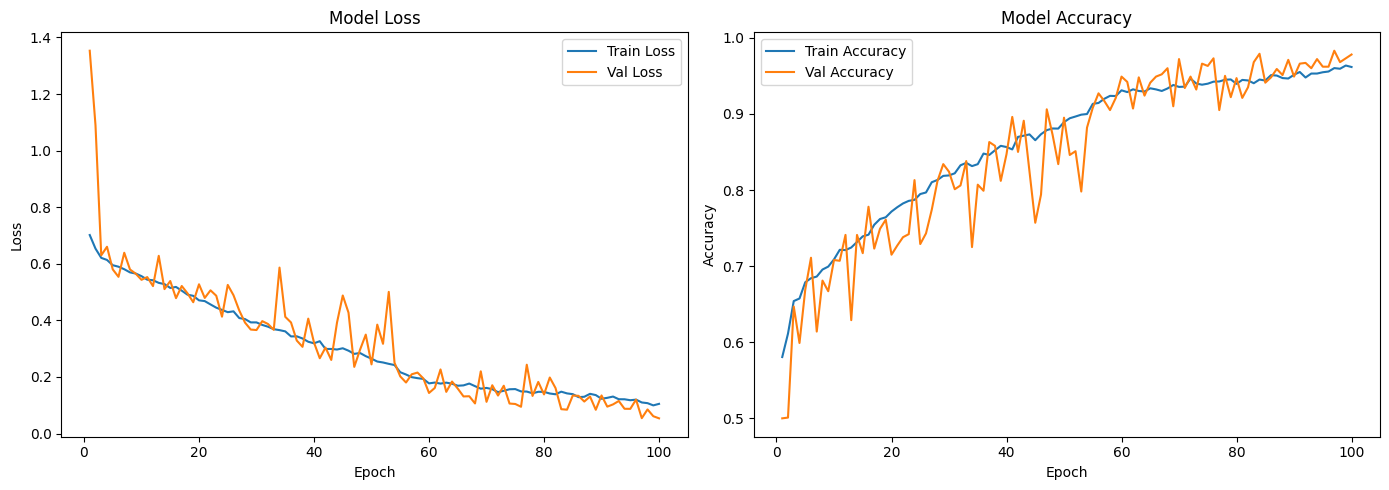

In [9]:
# ── Visualize training curves ──
import pandas as pd
model_information = pd.DataFrame(history.history)

epochs_ran = len(model_information)
x_axis = range(1, epochs_ran + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(x_axis, model_information['loss'], label='Train Loss')
plt.plot(x_axis, model_information['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x_axis, model_information['accuracy'], label='Train Accuracy')
plt.plot(x_axis, model_information['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


In [10]:
# ── Test data setup ──
from tensorflow.keras.preprocessing import image

test_data_path = "/kaggle/input/datasets/t2obd1a1253kmit/clean-augmented-anemia-dataset/New_Augmented_Anemia_Dataset/Conjuctiva/Testing"
test_images = []
for item in os.listdir(test_data_path):
    for img_file in os.listdir(os.path.join(test_data_path, item)):
        test_images.append([os.path.join(test_data_path, item, img_file), item])

random.shuffle(test_images)

class_names = train_generator.class_indices
classes = list(class_names.keys())
print(f"Classes: {classes}")

# ── Preprocess function ──
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(128, 128))
    img = image.img_to_array(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img

Classes: ['Anemic', 'Non-Anemic']


In [11]:
# ── Evaluate on validation set ──
print("\nEvaluating on validation set...")
test_data_eval = model.evaluate(valid_generator)
print(f"Val Loss: {test_data_eval[0]:.4f} | Val Accuracy: {test_data_eval[1]:.4f}")

# ── Get all predictions with details ──
print("\nGenerating predictions on test set...")
all_predictions = []
for img_path, real_label in test_images:
    img = preprocess_image(img_path)
    prediction = model.predict(img, verbose=0)
    score = float(prediction[0][0])
    predicted_class = classes[int(round(score))]
    confidence = score if predicted_class == 'Non-Anemic' else 1 - score
    all_predictions.append({
        'path': img_path,
        'real': real_label,
        'predicted': predicted_class,
        'score': score,
        'confidence': confidence
    })


Evaluating on validation set...
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.9720 - loss: 0.0657 - precision: 0.9485 - recall: 0.9956
Val Loss: 0.0539 | Val Accuracy: 0.9780

Generating predictions on test set...



── Confidence Scores (first 14) ──
Image  1 | Real: Anemic       | Predicted: Anemic       | Confidence: 0.9751 (97.5%)
Image  2 | Real: Non-Anemic   | Predicted: Non-Anemic   | Confidence: 0.8489 (84.9%)
Image  3 | Real: Non-Anemic   | Predicted: Non-Anemic   | Confidence: 0.9994 (99.9%)
Image  4 | Real: Non-Anemic   | Predicted: Non-Anemic   | Confidence: 1.0000 (100.0%)
Image  5 | Real: Anemic       | Predicted: Anemic       | Confidence: 0.9980 (99.8%)
Image  6 | Real: Non-Anemic   | Predicted: Non-Anemic   | Confidence: 1.0000 (100.0%)
Image  7 | Real: Anemic       | Predicted: Anemic       | Confidence: 0.9532 (95.3%)
Image  8 | Real: Anemic       | Predicted: Anemic       | Confidence: 0.9986 (99.9%)
Image  9 | Real: Anemic       | Predicted: Anemic       | Confidence: 0.9841 (98.4%)
Image 10 | Real: Non-Anemic   | Predicted: Non-Anemic   | Confidence: 1.0000 (100.0%)
Image 11 | Real: Non-Anemic   | Predicted: Non-Anemic   | Confidence: 0.9973 (99.7%)
Image 12 | Real: Anemic   

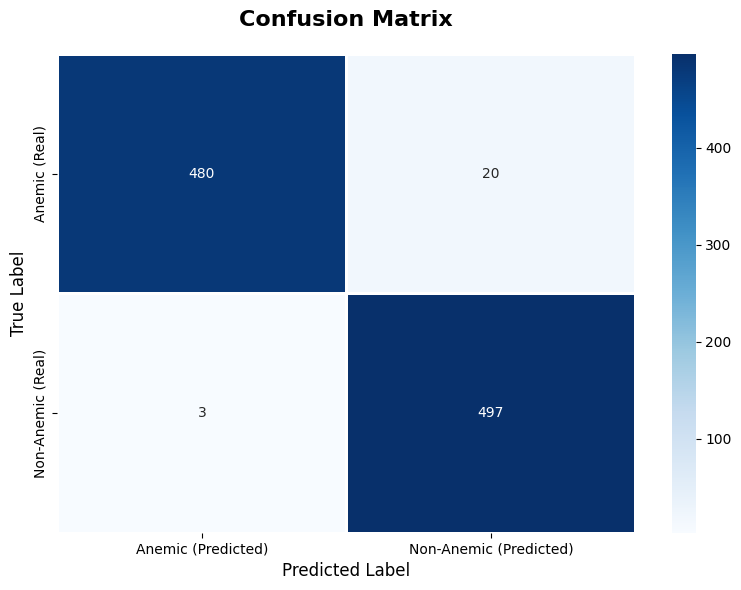

In [12]:

# ── Confidence scores ──
print("\n── Confidence Scores (first 14) ──")
for i, pred in enumerate(all_predictions[:14]):
    print(f"Image {i+1:2d} | Real: {pred['real']:12s} | Predicted: {pred['predicted']:12s} | Confidence: {pred['confidence']:.4f} ({pred['confidence']*100:.1f}%)")

# ── Confusion Matrix ──
print("\n── Confusion Matrix ──")
y_true = [1 if p['real'] == 'Non-Anemic' else 0 for p in all_predictions]
y_pred = [1 if p['predicted'] == 'Non-Anemic' else 0 for p in all_predictions]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Anemic (Predicted)', 'Non-Anemic (Predicted)'],
    yticklabels=['Anemic (Real)', 'Non-Anemic (Real)'],
    linewidths=1,
    linecolor='white'
)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Print classification report
print("\n── Classification Report ──")
print(classification_report(y_true, y_pred, target_names=['Anemic', 'Non-Anemic']))

# ── Categorize predictions ──
true_positives  = [p for p in all_predictions if p['real'] == 'Non-Anemic' and p['predicted'] == 'Non-Anemic']
true_negatives  = [p for p in all_predictions if p['real'] == 'Anemic'     and p['predicted'] == 'Anemic']
false_positives = [p for p in all_predictions if p['real'] == 'Anemic'     and p['predicted'] == 'Non-Anemic']
false_negatives = [p for p in all_predictions if p['real'] == 'Non-Anemic' and p['predicted'] == 'Anemic']

print(f"\n── Prediction Categories ──")
print(f"True Positives  (correctly predicted Non-Anemic): {len(true_positives)}")
print(f"True Negatives  (correctly predicted Anemic):     {len(true_negatives)}")
print(f"False Positives (predicted Non-Anemic, was Anemic): {len(false_positives)}")
print(f"False Negatives (predicted Anemic, was Non-Anemic): {len(false_negatives)}")


── Classification Report ──
              precision    recall  f1-score   support

      Anemic       0.99      0.96      0.98       500
  Non-Anemic       0.96      0.99      0.98       500

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


── Prediction Categories ──
True Positives  (correctly predicted Non-Anemic): 497
True Negatives  (correctly predicted Anemic):     480
False Positives (predicted Non-Anemic, was Anemic): 20
False Negatives (predicted Anemic, was Non-Anemic): 3



── Visualizing samples by category ──


/tmp/ipykernel_57/489361219.py:40: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/489361219.py:42: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(fname, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


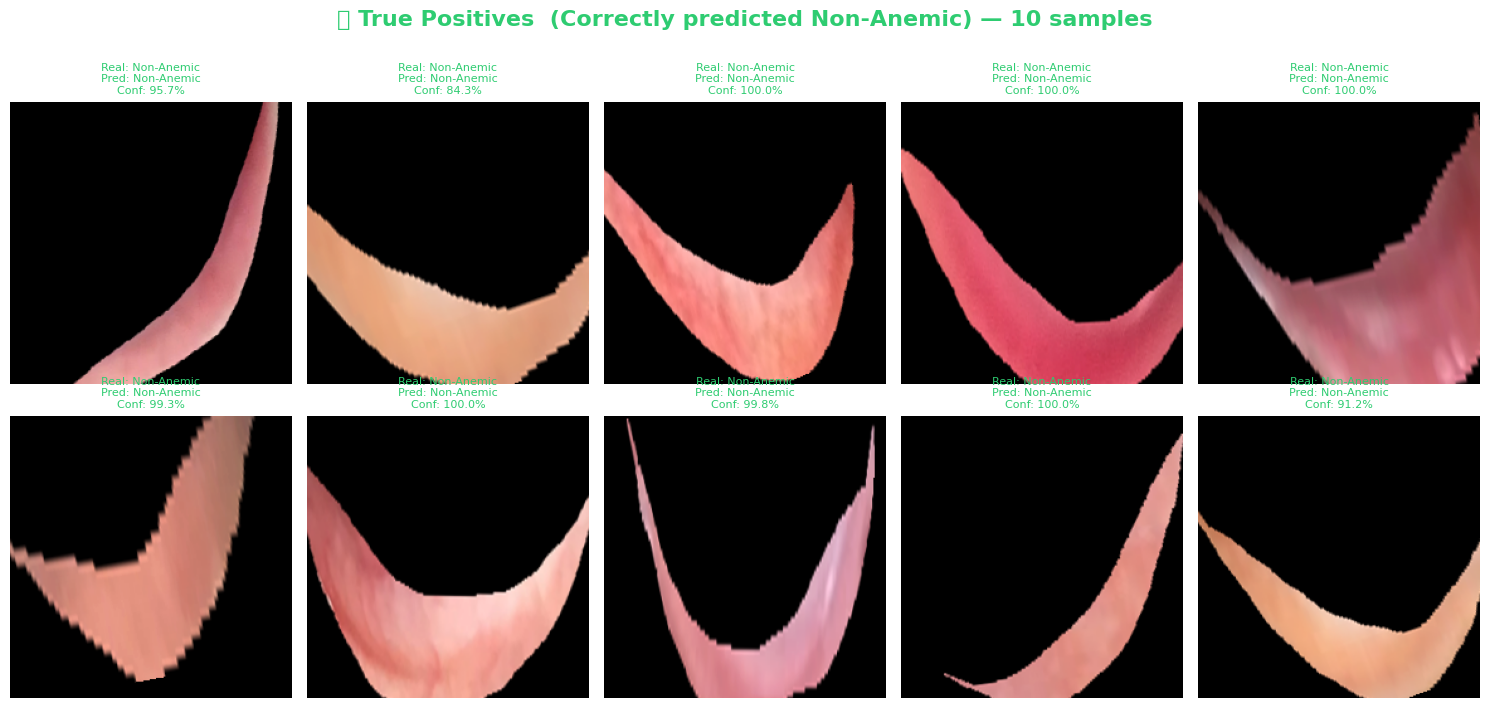

Saved: ✅_true_positives__(correctly_predicted_non-anemic)_samples.png


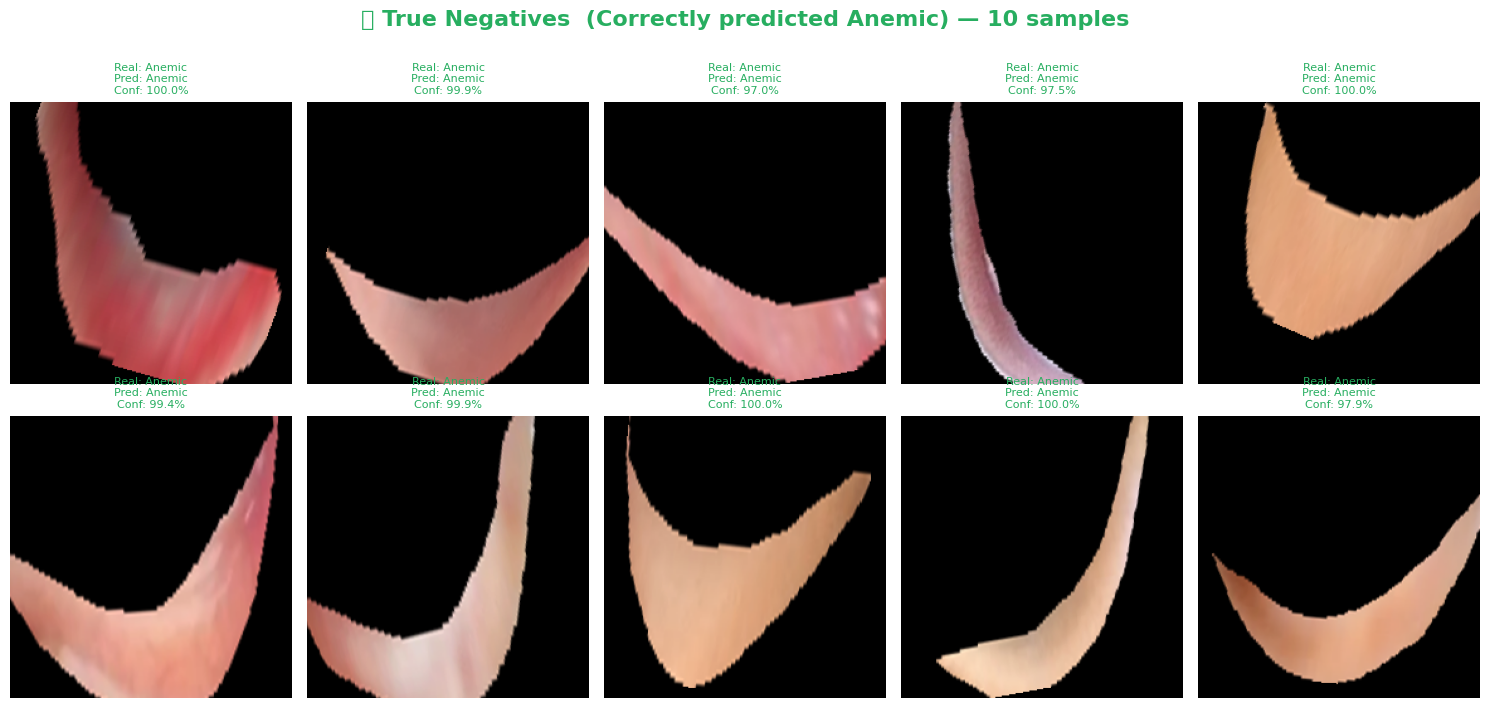

Saved: ✅_true_negatives__(correctly_predicted_anemic)_samples.png


/tmp/ipykernel_57/489361219.py:40: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/489361219.py:42: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(fname, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


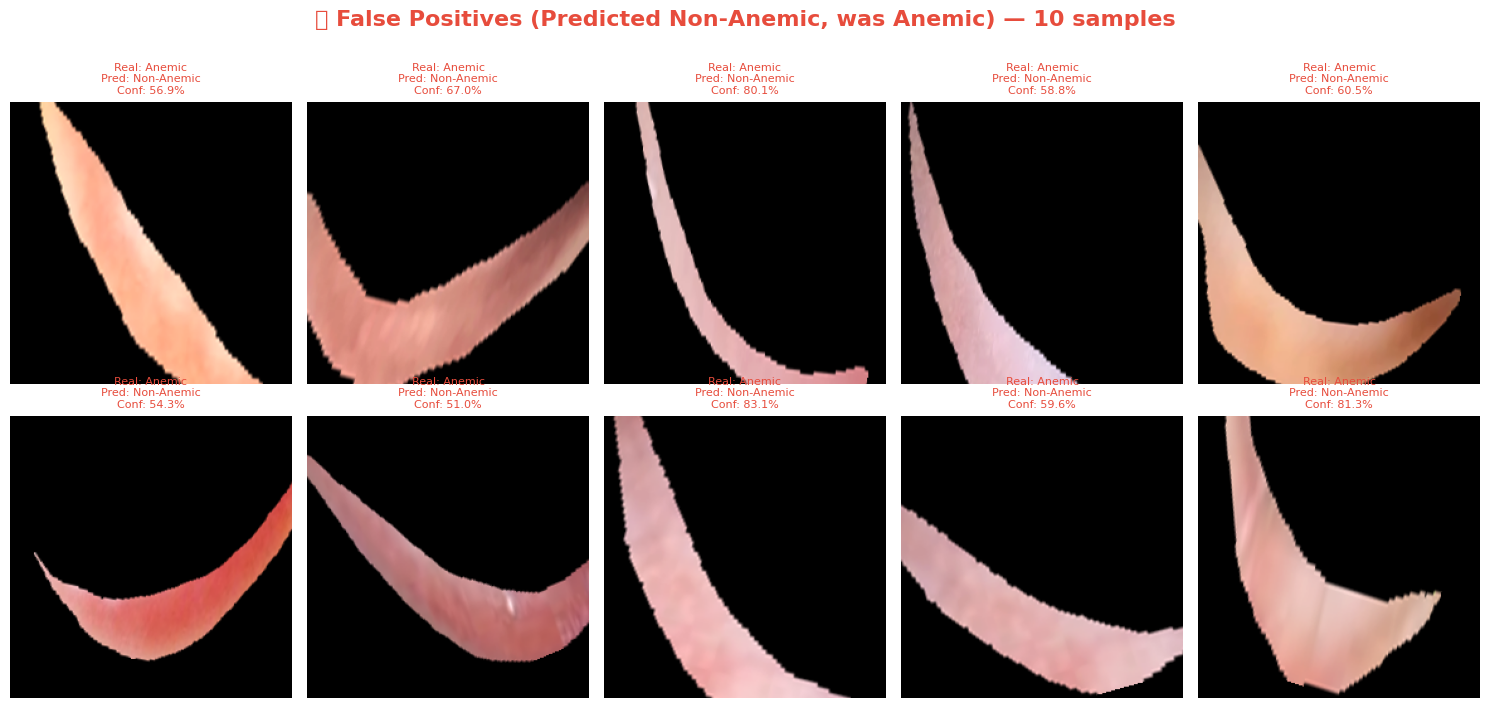

Saved: ❌_false_positives_(predicted_non-anemic,_was_anemic)_samples.png


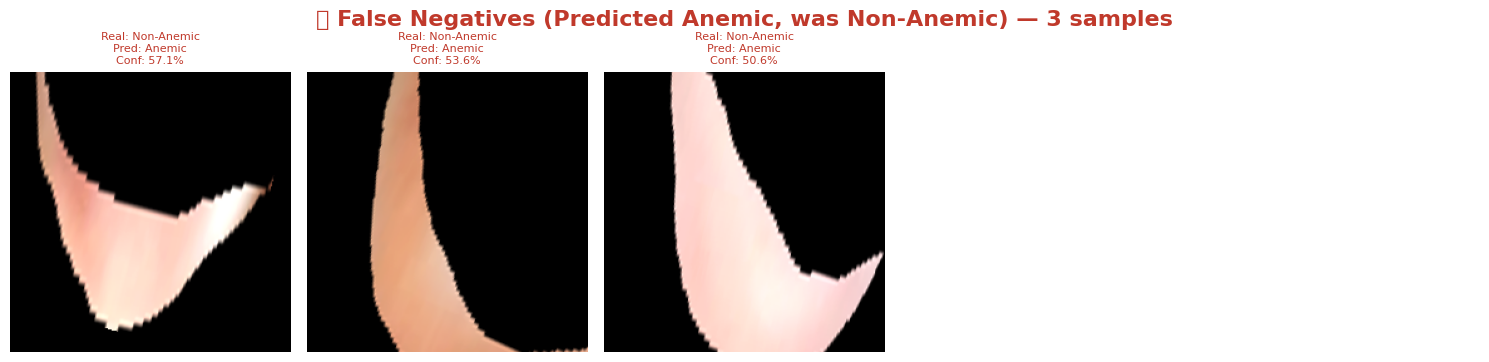

Saved: ❌_false_negatives_(predicted_anemic,_was_non-anemic)_samples.png

✅ All done!


In [14]:

# ── Visualize samples from each category ──
def visualize_category(samples, category_name, color, n=10):
    if not samples:
        print(f"No samples found for: {category_name}")
        return

    n = min(n, len(samples))
    selected = random.sample(samples, n)

    cols = 5
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    axes = axes.flatten() if n > 1 else [axes]

    fig.suptitle(
        f'{category_name} — {n} samples',
        fontsize=16,
        fontweight='bold',
        color=color,
        y=1.02
    )

    for i, pred in enumerate(selected):
        img = image.load_img(pred['path'])
        axes[i].imshow(img)
        axes[i].set_title(
            f"Real: {pred['real']}\nPred: {pred['predicted']}\nConf: {pred['confidence']*100:.1f}%",
            fontsize=8,
            color=color
        )
        axes[i].axis('off')
        for spine in axes[i].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    fname = category_name.lower().replace(' ', '_') + '_samples.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

print("\n── Visualizing samples by category ──")
visualize_category(true_positives,  '✅ True Positives  (Correctly predicted Non-Anemic)', '#2ECC71')
visualize_category(true_negatives,  '✅ True Negatives  (Correctly predicted Anemic)',     '#27AE60')
visualize_category(false_positives, '❌ False Positives (Predicted Non-Anemic, was Anemic)', '#E74C3C')
visualize_category(false_negatives, '❌ False Negatives (Predicted Anemic, was Non-Anemic)', '#C0392B')

print("\n✅ All done!")